Original Data:
    Feature1  Feature2  Label
0         2         1      0
1         4         3      0
2         6         5      0
3         8         7      1
4        10         9      1
5        12        11      1
6        14        13      1
7        16        15      1

Missing Values:
 Feature1    0
Feature2    0
Label       0
dtype: int64

Accuracy: 1.0

Confusion Matrix:
 [[1 0]
 [0 1]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



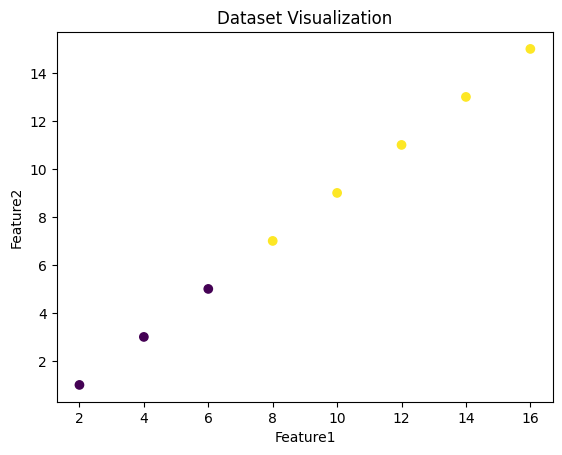

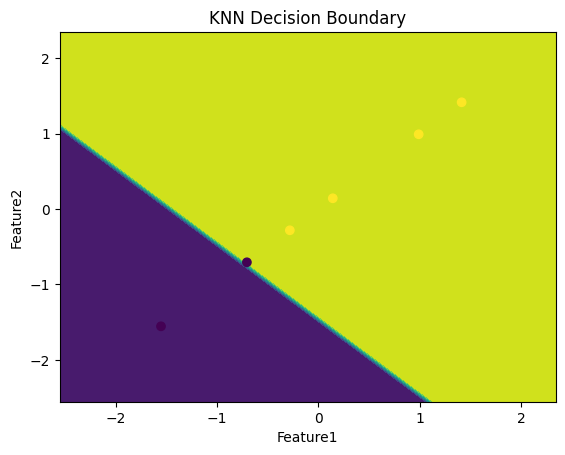

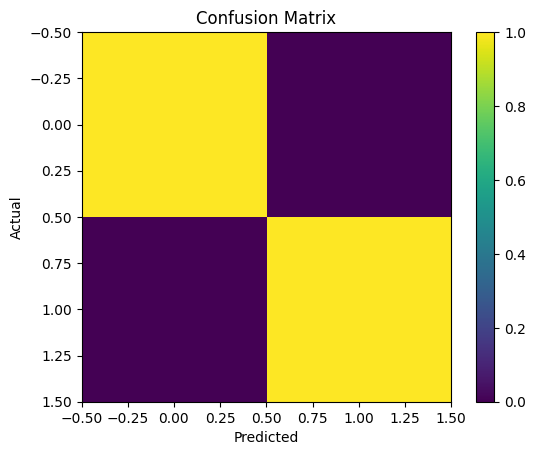


KNN with Graphs Completed


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# create dataset
data = pd.DataFrame({
    "Feature1": [2, 4, 6, 8, 10, 12, 14, 16],
    "Feature2": [1, 3, 5, 7, 9, 11, 13, 15],
    "Label":    [0, 0, 0, 1, 1, 1, 1, 1]
})

print("Original Data:\n", data)

# check missing values
print("\nMissing Values:\n", data.isnull().sum())

# fill missing values
data.fillna(data.mean(numeric_only=True), inplace=True)

# split features and target
X = data.drop("Label", axis=1)
y = data["Label"]

# split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# apply knn model
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

# predictions
y_pred = model.predict(X_test)

# evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# scatter plot of dataset
plt.figure()
plt.scatter(data["Feature1"], data["Feature2"], c=data["Label"])
plt.title("Dataset Visualization")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.show()

# decision boundary plot
plt.figure()
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
plt.title("KNN Decision Boundary")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.show()

# confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

print("\nKNN with Graphs Completed")